In [4]:
import torch 
import lightning as L
import yaml
import sys, os
sys.path.append('../')
sys.path.append('./')
import importlib
from pathlib import Path 
# from byol_a.models import AudioNTT2020



In [15]:
sys.path.append("lightning_scripts")
import lightning_scripts.eval_jsin_transfer_matched as lightning 
from byol_a.common import *

importlib.reload(lightning)
BYOLAClassifier = lightning.BYOLAClassifier

config_path = 'byol-a/config.yaml'
config = load_yaml_config(config_path)

config['model'] = {}
config['hparas'] = {}
config['hparas']['task_loss_params'] = {
    "signal/word_int":
      {"loss_type": 'crossentropyloss',
      "weight": 1.0},                       # init loss is ~6.6 
   "noise/labels_int":
      {"loss_type": 'bcewithlogitsloss',
      "weight": 1.0},                      # init loss is ~200 
    "signal/speaker_int":
      {"loss_type": 'crossentropyloss',
      "weight": 1.0}
    }

config['audio_transforms'] = {} 
config['audio_transforms']['low_snr'] = -10
config['audio_transforms']['high_snr'] = 10
config['audio_transforms']['rms_level'] = 60

config['model']['arch_kwargs'] = {}
config['data'] = {}
config['model']['arch_kwargs']['num_classes'] = {"signal/word_int": 794} 
config['hparas']['batch_size'] = 32
config['hparas']['lr'] = 0.01
config['data']['eval_max'] = 3
config['hparas']['optimizer'] = "AdamW"
config['hparas']['epochs'] = 1
config['num_workers'] = 1 
config['with_noise'] = True

config['hparas']['task_loss_params'] = {key:value for key,value in config['hparas']['task_loss_params'].items() if key in config['model']['arch_kwargs']['num_classes'].keys()}


# task_config = {}
# task_config['num_classes'] = 784



module = BYOLAClassifier(config)

/mnt/ceph/users/igriffith/projects/cochdnn/byol-a/byol_a/models.py:23: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = state_dict or torch.load(weight_file, map_l

In [102]:
### Compute training stats 

training_dataset = module.train_dataloader()

KeyboardInterrupt: 

In [82]:
module.stats

[10158236.0, 51190964.0]

In [58]:
from tqdm import tqdm 

n_stats = 10_000 

examples = torch.zeros(n_stats, 64, 251)
for ix, batch in enumerate(tqdm(training_dataset, total=n_stats)):
    if ix == n_stats:
        break 
    examples[ix] = module.to_melspec(batch[0]).squeeze(0)


  0%|          | 0/10000 [00:00<?, ?it/s]

100%|██████████| 10000/10000 [01:05<00:00, 151.86it/s]


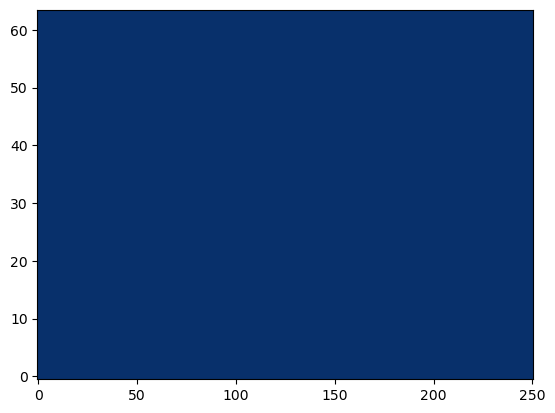

In [ ]:
plt.imshow(module.to_melspec(batch[0]).squeeze(0).squeeze(0),
          aspect='auto',
          origin='lower',
            vmin=0,vmax=1,

          cmap='Blues')

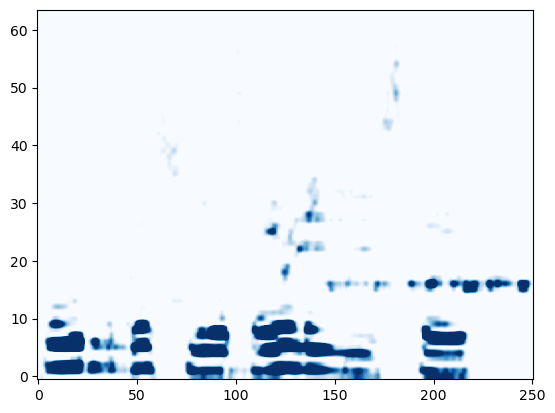

In [90]:
plt.imshow(module.normalizer(module.to_melspec(batch[0]).squeeze(0).squeeze(0)),
          aspect='auto',
          origin='lower',
          vmin=0,vmax=1,
          cmap='Blues')

In [75]:
examples.shape

torch.Size([10000, 64, 251])

In [77]:
### Get stats 
mean, std = examples.mean().numpy(), examples.std().numpy()
mean,std

(array(10158236., dtype=float32), array(51190964., dtype=float32))

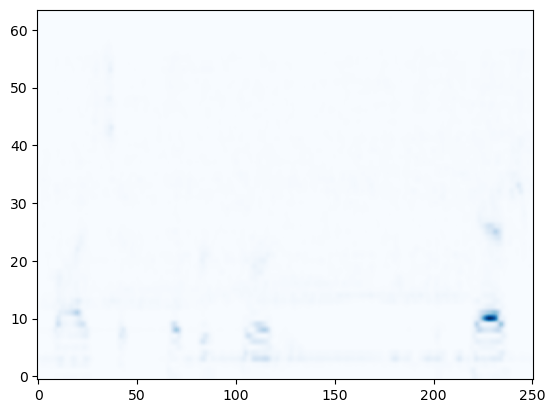

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt 
# plt.imshow(examples[3], aspect='auto', origin='lower', cmap='Blues')

In [17]:
### Try training loop 
trainer = L.Trainer(devices=1)
trainer.fit(module)


/mnt/home/igriffith/envs/cochdnn_ssl_pl/lib/python3.12/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /mnt/home/igriffith/envs/cochdnn_ssl_pl/lib/python3. ...
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/mnt/home/igriffith/envs/cochdnn_ssl_pl/lib/python3.12/site-packages/lightning/pytorch/loops/utilities.py:72: `max_epochs` was not set. Setting it to 1000 epochs. To train without an epoch limit, set `max_epochs=-1`.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name              | Type                   | Params | Mode 
---------------------------------------------------------------------
0 | to_melspec        | MelSpectrogram         | 0      | train
1 | transforms        | AudioCompose           | 0      | train
2 | n

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/mnt/home/igriffith/envs/cochdnn_ssl_pl/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:424: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=3` in the `DataLoader` to improve performance.
/mnt/home/igriffith/envs/cochdnn_ssl_pl/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:424: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=3` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]


Detected KeyboardInterrupt, attempting graceful shutdown ...


NameError: name 'exit' is not defined

In [16]:
for name, param in module.feature_extractor.named_parameters():
    print(f"Layer: {name}, Trainable: {param.requires_grad}")

Layer: features.0.weight, Trainable: False
Layer: features.0.bias, Trainable: False
Layer: features.1.weight, Trainable: False
Layer: features.1.bias, Trainable: False
Layer: features.4.weight, Trainable: False
Layer: features.4.bias, Trainable: False
Layer: features.5.weight, Trainable: False
Layer: features.5.bias, Trainable: False
Layer: features.8.weight, Trainable: False
Layer: features.8.bias, Trainable: False
Layer: features.9.weight, Trainable: False
Layer: features.9.bias, Trainable: False
Layer: fc.0.weight, Trainable: False
Layer: fc.0.bias, Trainable: False
Layer: fc.3.weight, Trainable: False
Layer: fc.3.bias, Trainable: False
